# Benchmark Knill quantum error correction

Knill quantum error correction (QEC) transfers an encoded state into a fresh code block by teleportation through an encoded Bell pair.
The Bell-basis measurement outcomes both complete the teleportation and supply the syndrome information needed to perform QEC.

Knill QEC requires the capability to prepare an encoded Bell pair fault tolerantly.
The notebook assembles one Steane-code cycle explicitly, keeping the three code blocks, diagnostic reference qubits, detector annotations, logical observables, and state-preparation flags visible before benchmarking logical and discard rates.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import sinter
import stim
from matplotlib.figure import Figure

from qldpc import circuits, codes, decoders
from qldpc.objects import Pauli

In [3]:
def plot_error_and_discard_rates(
    error_rates: npt.NDArray[np.float64],
    logical_error_rates: npt.NDArray[np.float64],
    logical_error_low: npt.NDArray[np.float64],
    logical_error_high: npt.NDArray[np.float64],
    discard_rates: npt.NDArray[np.float64],
    discard_low: npt.NDArray[np.float64],
    discard_high: npt.NDArray[np.float64],
) -> tuple[Figure, npt.NDArray[np.object_]]:
    """Plot logical-error and discard-rate estimates with uncertainty bounds."""
    figure, axes = plt.subplots(1, 2, sharex=True, figsize=(7.5, 3.2))

    positive = logical_error_rates > 0
    logical_line, *_ = axes[0].plot(
        error_rates[positive],
        logical_error_rates[positive],
        marker="o",
        label="Knill QEC",
    )
    axes[0].fill_between(
        error_rates,
        logical_error_low,
        logical_error_high,
        color=logical_line.get_color(),
        alpha=0.18,
    )
    axes[0].plot(
        [error_rates.min(), error_rates.max()],
        [error_rates.min(), error_rates.max()],
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axes[0].set_ylabel("estimated logical error rate")

    discard_line, *_ = axes[1].plot(
        error_rates,
        discard_rates,
        marker="s",
        linestyle="--",
        label="flag discard",
    )
    axes[1].fill_between(
        error_rates,
        discard_low,
        discard_high,
        color=discard_line.get_color(),
        alpha=0.18,
    )
    axes[1].set_ylabel("estimated discard rate")

    for axis in axes:
        axis.set_xlabel("physical error rate per operation")
        axis.loglog()
        axis.grid(which="both", alpha=0.3)
        axis.legend(loc="best")
    figure.tight_layout()
    return figure, axes

## Encoded ancilla blocks

The flagged circuit prepares logical zero.
Applying transversal Hadamards to its seven data qubits gives the matching logical-plus preparation.
The eighth qubit is a flag and is not transformed.


In [4]:
code = codes.SteaneCode()

# |0> state prep circuit
zero_prep_circuit = stim.Circuit("""
    # non-fault-tolerant state preparation
    H 0 2 4
    CX 0 3 2 1 4 5
    CX 0 1 2 6 4 3
    CX 2 5 3 6
    # flag errors in a logical Z representative
    H 7
    CZ 7 1 7 3 7 5
    MX 7
    DETECTOR rec[-1]  # post-selection flag
""")

# |+> state prep circuit
plus_prep_circuit = zero_prep_circuit.copy()
plus_prep_circuit.append("H", range(len(code)))

## Allocate qubits and records

Block 0 holds the input, blocks 1 and 2 form the encoded Bell pair, and noiseless reference qubits let the simulation track both X- and Z-type logical observables.
`MeasurementRecord` and `DetectorRecord` keep later annotations tied to the measurements that define them.


In [5]:
# Identify the qubits used by each code block.
# The method circuits.QubitIDs.from_code(code) will automatically allocate len(code) data qubits
# and len(code.matrix) "check" qubits (one for each stabilizer).  You can additionally pass
# QubitIDs.from_code(code, num_references=...) to allocate ideal reference qubits.
qubit_ids_0 = circuits.QubitIDs.from_code(code, num_references=code.dimension)
qubit_ids_1 = qubit_ids_0.shifted(qubit_ids_0.max() + 1)
qubit_ids_2 = qubit_ids_1.shifted(qubit_ids_1.max() + 1)

# records to keep track of measurements and detectors in the circuit we build
meas_record = circuits.MeasurementRecord()
det_record = circuits.DetectorRecord()

## Assemble the teleportation circuit

The Bell-basis measurements on blocks 0 and 1 are grouped according to the Steane-code stabilizers. Each stabilizer parity should be +1 in the ideal circuit, so a -1 parity is recorded as a detector event. The corresponding logical parities determine the Pauli-frame correction to the teleported state and are therefore included in Stim's tracked logical observables.

Finally, every stabilizer of the output block (block 2) is measured without adding readout noise. A -1 result then reveals a residual error on that block at the end of the cycle. The logical operators on block 2 complete the comparison between the teleported state and the original encoded state.


In [6]:
# initialize empty circuit
circuit = stim.Circuit()

# prepare a logical Bell-pair state noiselessly on code block 0, and annotate its observables
circuit += circuits.get_logical_bell_prep(
    code,
    data_qubits=qubit_ids_0.data,
    reference_qubits=qubit_ids_0.reference,
)
circuit += circuits.get_observables(code, qubit_ids_0.data)

# prepare blocks 1 and 2 in a logical Bell state, and record flag detectors for post-selection
circuit += circuits.with_remapped_qubits(plus_prep_circuit, qubit_ids_1.all_qubits)
circuit += circuits.with_remapped_qubits(zero_prep_circuit, qubit_ids_2.all_qubits)
for cc, tt in zip(qubit_ids_1.data, qubit_ids_2.data):
    circuit.append("CX", [cc, tt])
det_record.append({"flags": range(circuit.num_detectors)})

# measure blocks 0 and 1 in the Bell basis, keeping a record of the measurements
for cc, tt in zip(qubit_ids_0.data, qubit_ids_1.data):
    circuit.append("CX", [cc, tt])
circuit.append("MX", qubit_ids_0.data)
circuit.append("MZ", qubit_ids_1.data)
meas_record.append(
    {qubit: meas_index for meas_index, qubit in enumerate(qubit_ids_0.data + qubit_ids_1.data)}
)

# Annotate stabilizers (detectors) supported on the measurements of blocks 0 and 1,
# as well as the observables flipped by logical corrections from these measurement outcomes.
for data_qubits, basis in [
    (qubit_ids_0.data, Pauli.X),
    (qubit_ids_1.data, Pauli.Z),
]:
    # stabilizers
    for op_vec in code.get_stabilizer_ops(basis):
        support = [data_qubits[qubit] for qubit in range(len(code)) if op_vec[qubit]]
        target_recs = [meas_record.get_target_rec(qubit) for qubit in support]
        circuit.append("DETECTOR", target_recs)
    # observables
    for index, op_vec in enumerate(code.get_logical_ops(basis)):
        support = [data_qubits[qubit] for qubit in range(len(code)) if op_vec[qubit]]
        target_recs = [meas_record.get_target_rec(qubit) for qubit in support]
        # X-type observables are numbered from 0 to code.dimension-1, while
        # Z-type observables are numbered from code.dimension to 2*code.dimension-1.
        observable_index = index + code.dimension * int(basis)
        circuit.append("OBSERVABLE_INCLUDE", target_recs, [observable_index])

# append final (noiseless) stabilizer and observable readout
circuit += circuits.as_noiseless_circuit(
    circuits.get_pauli_product_measurements(code.get_stabilizer_ops(), qubit_ids_2.data)
)
for index in range(len(code.get_stabilizer_ops())):
    circuit.append("DETECTOR", [stim.target_rec(-index - 1)])
circuit += circuits.get_observables(code, qubit_ids_2.data)

## Add noise, decode, and post-select

A shot is discarded when any of the state-preparation flag detectors recorded above fires.
The reported logical error rate is conditioned on the shots that survive this post-selection, so it must be interpreted together with the discard rate.

The shaded bands contain rates whose binomial likelihood is within a factor of 1,000 of the best fit. At a point with no observed logical failures, the logical-rate band is one-sided: it extends from zero to the fitted upper bound.


In [7]:
error_rates = np.logspace(-4, -2, 5)
sinter_decoder = decoders.SinterDecoder(with_lookup=True, max_weight=3, add_erasure_bit=True)

logical_error_rates = np.empty_like(error_rates)
logical_error_low = np.empty_like(error_rates)
logical_error_high = np.empty_like(error_rates)
discard_rates = np.empty_like(error_rates)
discard_low = np.empty_like(error_rates)
discard_high = np.empty_like(error_rates)
num_samples = 100_000

for index, error_rate in enumerate(error_rates):
    noise_model = circuits.DepolarizingNoiseModel(error_rate)
    noisy_circuit = noise_model.noisy_circuit(circuit)
    logical_error_rates[index], discard_rates[index] = circuits.get_logical_error_and_discard_rate(
        noisy_circuit,
        sinter_decoder,
        num_samples=num_samples,
        post_select=det_record.get_events("flags"),
    )

    num_discards = round(discard_rates[index] * num_samples)
    num_kept = num_samples - num_discards
    num_failures = round(logical_error_rates[index] * num_kept)
    logical_fit = sinter.fit_binomial(
        num_shots=num_kept,
        num_hits=num_failures,
        max_likelihood_factor=1_000,
    )
    discard_fit = sinter.fit_binomial(
        num_shots=num_samples,
        num_hits=num_discards,
        max_likelihood_factor=1_000,
    )
    logical_error_low[index] = logical_fit.low
    logical_error_high[index] = logical_fit.high
    discard_low[index] = discard_fit.low
    discard_high[index] = discard_fit.high
    print(
        f"p={error_rate:.4g}: failures={num_failures}/{num_kept} kept, "
        f"discards={num_discards}/{num_samples}"
    )

p=0.0001: failures=0/99869 kept, discards=131/100000


p=0.0003162: failures=7/99505 kept, discards=495/100000


p=0.001: failures=31/98572 kept, discards=1428/100000


p=0.003162: failures=268/95498 kept, discards=4502/100000


p=0.01: failures=2271/86481 kept, discards=13519/100000


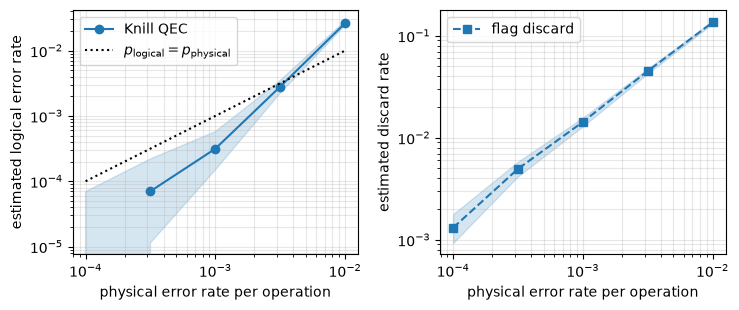

In [8]:
plot_error_and_discard_rates(
    error_rates,
    logical_error_rates,
    logical_error_low,
    logical_error_high,
    discard_rates,
    discard_low,
    discard_high,
)
plt.show()

A trend across five sampled physical error rates does not by itself establish a threshold.
This notebook is instead a worked example of Knill-cycle assembly and a regression-sized comparison of one noise model, decoder, and post-selection rule.
